In [ ]:
!pip install skyfield


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from skyfield.api import load
from tqdm import tqdm

In [ ]:
import pandas as pd

file_1 = "30000-30050.csv"
file_2 = "30050-30100.csv" 

output_file = "100_sats_raw.csv"

print("Reading files...")
try:
    df1 = pd.read_csv(file_1, low_memory=False, on_bad_lines='skip')
    df2 = pd.read_csv(file_2, low_memory=False, on_bad_lines='skip')

    print(f"File 1 rows: {len(df1)}")
    print(f"File 2 rows: {len(df2)}")

    df_combined = pd.concat([df1, df2])

    df_combined.to_csv(output_file, index=False)

    print(f"\nSuccess! Combined file saved as: {output_file}")
    print(f"Total rows: {len(df_combined)}")
    print(f"Unique Satellites: {df_combined['NORAD_CAT_ID'].nunique()}")
    print("\nNow use this filename in 'process_bulk_csv.py'")

except Exception as e:
    print(f"Error merging files: {e}")

Reading files...
File 1 rows: 79654
File 2 rows: 87944

Success! Combined file saved as: 100_sats_raw.csv
Total rows: 167598
Unique Satellites: 82

Now use this filename in 'process_bulk_csv.py'


In [ ]:
import pandas as pd
import numpy as np
from skyfield.api import EarthSatellite, load
from tqdm import tqdm

INPUT_CSV = "100_sats_raw.csv"
OUTPUT_MASTER = "MASTER_hybrid_training_data.csv"

ts = load.timescale()


print(f"Loading bulk CSV: {INPUT_CSV}...")

try:
    df_raw = pd.read_csv(INPUT_CSV, low_memory=False)
except Exception as e:
    print(f"Error reading CSV: {e}")
    exit()

df_raw = df_raw[pd.to_numeric(df_raw['NORAD_CAT_ID'], errors='coerce').notnull()]

df_raw['NORAD_CAT_ID'] = df_raw['NORAD_CAT_ID'].astype(int)

if 'TLE_LINE1' not in df_raw.columns or 'TLE_LINE2' not in df_raw.columns:
    print("Error: Columns 'TLE_LINE1' and 'TLE_LINE2' are required.")
    print("Your columns are:", df_raw.columns)
    exit()

print(f"Found {len(df_raw)} valid rows.")
print(f"Unique Satellites: {df_raw['NORAD_CAT_ID'].nunique()}")

hybrid_data_list = []

print("Processing satellites...")
grouped = df_raw.groupby('NORAD_CAT_ID')

for sat_id, group in tqdm(grouped):

    sats = []
    valid_rows = []

    for _, row in group.iterrows():
        line1 = row['TLE_LINE1']
        line2 = row['TLE_LINE2']

        if not isinstance(line1, str) or not isinstance(line2, str):
            continue

        try:
            sat = EarthSatellite(line1, line2, str(sat_id), ts)
            sats.append(sat)
            valid_rows.append(row)
        except Exception:
            continue

    if len(sats) < 2:
        continue

    paired = sorted(zip(sats, valid_rows), key=lambda x: x[0].epoch.tt)
    sats, valid_rows = zip(*paired) 
    for i in range(1, len(sats)):
        sat_t0 = sats[i-1] 
        sat_t1 = sats[i]   

        t1_epoch = sat_t1.epoch

        try:
            predicted_pos = sat_t0.at(t1_epoch).position.km
            actual_pos = sat_t1.at(t1_epoch).position.km
        except Exception:
            continue 

        error_vector = actual_pos - predicted_pos

        model = sat_t0.model

        if np.isnan(model.inclo) or np.isnan(model.ecco):
            continue

        new_record = {
            'norad_id': sat_id,
            'time_jd': sat_t0.epoch.tt,
            'mean_motion_rev_day': model.no_kozai * (1440.0 / (2 * np.pi)),
            'eccentricity': model.ecco,
            'bstar_drag': model.bstar,
            'inclination_deg': np.rad2deg(model.inclo),
            'raan_deg': np.rad2deg(model.nodeo),
            'arg_perigee_deg': np.rad2deg(model.argpo),
            'mean_anomaly_deg': np.rad2deg(model.mo),
            'delta_t_days': sat_t1.epoch.tt - sat_t0.epoch.tt,
            'error_x_km': error_vector[0],
            'error_y_km': error_vector[1],
            'error_z_km': error_vector[2]
        }
        hybrid_data_list.append(new_record)

master_df = pd.DataFrame(hybrid_data_list)

master_df = master_df.dropna()

master_df = master_df.sort_values(by=['norad_id', 'time_jd'])

master_df.to_csv(OUTPUT_MASTER, index=False)

print("\n" + "="*30)
print(f"DONE! Processed {len(master_df)} training samples.")
print(f"Saved to {OUTPUT_MASTER}")
print("You can now run 'train_model.py' immediately.")

Loading bulk CSV: 100_sats_raw.csv...
Found 167598 valid rows.
Unique Satellites: 82
Processing satellites...


100%|██████████| 82/82 [02:03<00:00,  1.50s/it]



DONE! Processed 167516 training samples.
Saved to MASTER_hybrid_training_data.csv
You can now run 'train_model.py' immediately.


Loading Master Dataset...
Total Satellites Found: 82
Training Satellites: [30038 30000 30026 30039 30022 30036 30013 30066 30005 30016 30062 30041
 30081 30044 30082 30058 30090 30075 30069 30052 30012 30094 30007 30060
 30043 30079 30054 30068 30020 30050 30074 30095 30009 30099 30067 30023
 30080 30031 30057 30017 30071 30004 30021 30048 30010 30077 30008 30045
 30088 30078 30063 30059 30096 30019 30035 30053 30032 30061 30030 30056
 30087 30070 30015 30040 30093]
Testing Satellites (Unseen): [30072 30076 30085 30047 30037 30001 30065 30025 30003 30028 30092 30089
 30024 30073 30086 30018 30064]
Fitting StandardScalers...
Creating sequences...
Train Sequences: (134093, 14, 8)
Test Sequences:  (32275, 14, 8)
Building Model...
Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 96s 42ms/step - loss: 0.4334 - val_loss: 0.7704
Epoch 2/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 85s 41ms/step - loss: 0.5637 - val_loss: 0.7706
Epoch 3/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - loss: 0.8989 - val_loss: 0.7706
Epoch 4/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 142s 40ms/step - loss: 0.9600 - val_loss: 0.7706
Epoch 5/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - loss: 0.7037 - val_loss: 0.7705
Epoch 6/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - loss: 0.4317 - val_loss: 0.7704
Epoch 7/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - loss: 0.6373 - val_loss: 0.7706
Epoch 8/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 0.5421 - val_loss: 0.7706
Epoch 9/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 0.5097 - val_loss: 0.7707
Epoch 10/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - loss: 0.3277 - val_loss: 0.7713
Epoch 11/150
2096/2096 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 0.9925 - val_loss: 0.7

Model saved.


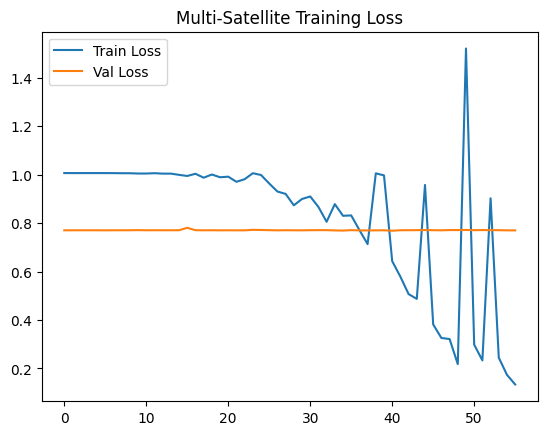

In [ ]:
#script 3
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

MASTER_CSV = "MASTER_hybrid_training_data.csv"
MODEL_FILE = "hybrid_residual_lstm.h5"
SCALER_X_FILE = "scaler_x.save"
SCALER_Y_FILE = "scaler_y.save"
TEST_IDS_FILE = "test_satellite_ids.npy"

LOOKBACK = 14 
FEATURES = ['mean_motion_rev_day', 'eccentricity', 'bstar_drag', 'inclination_deg',
            'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg', 'delta_t_days']
TARGETS = ['error_x_km', 'error_y_km', 'error_z_km']

print("Loading Master Dataset...")
df = pd.read_csv(MASTER_CSV)
all_sat_ids = df['norad_id'].unique()
print(f"Total Satellites Found: {len(all_sat_ids)}")

np.random.seed(42)
np.random.shuffle(all_sat_ids)

split_idx = int(len(all_sat_ids) * 0.8) 
train_ids = all_sat_ids[:split_idx]
test_ids = all_sat_ids[split_idx:]

np.save(TEST_IDS_FILE, test_ids)

print(f"Training Satellites: {train_ids}")
print(f"Testing Satellites (Unseen): {test_ids}")

df_train = df[df['norad_id'].isin(train_ids)].copy()
df_test = df[df['norad_id'].isin(test_ids)].copy()

print("Fitting StandardScalers...")
scaler_x = StandardScaler()
scaler_y = StandardScaler()

scaler_x.fit(df_train[FEATURES])
scaler_y.fit(df_train[TARGETS])

joblib.dump(scaler_x, SCALER_X_FILE)
joblib.dump(scaler_y, SCALER_Y_FILE)

df_train[FEATURES] = scaler_x.transform(df_train[FEATURES])
df_train[TARGETS] = scaler_y.transform(df_train[TARGETS])

df_test[FEATURES] = scaler_x.transform(df_test[FEATURES])
df_test[TARGETS] = scaler_y.transform(df_test[TARGETS])

def create_grouped_sequences(dataset, lookback):
    X_seq, y_seq = [], []

    for sat_id, group in dataset.groupby('norad_id'):
        group = group.sort_values('time_jd')

        data_x = group[FEATURES].values
        data_y = group[TARGETS].values

        if len(data_x) <= lookback:
            continue

        for i in range(len(data_x) - lookback):
            X_seq.append(data_x[i : i+lookback])
            y_seq.append(data_y[i+lookback])

    return np.array(X_seq), np.array(y_seq)

print("Creating sequences...")
X_train, y_train = create_grouped_sequences(df_train, LOOKBACK)
X_test, y_test = create_grouped_sequences(df_test, LOOKBACK)

print(f"Train Sequences: {X_train.shape}")
print(f"Test Sequences:  {X_test.shape}")

print("Building Model...")
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(LOOKBACK, len(FEATURES))),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("Training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

model.save(MODEL_FILE)
print("Model saved.")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Multi-Satellite Training Loss')
plt.show()

In [ ]:

import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

MASTER_CSV = "MASTER_hybrid_training_data.csv"
MODEL_FILE = "hybrid_residual_lstm.h5"
SCALER_X_FILE = "scaler_x.save"
SCALER_Y_FILE = "scaler_y.save"
TEST_IDS_FILE = "test_satellite_ids.npy"

FEATURES = ['mean_motion_rev_day', 'eccentricity', 'bstar_drag', 'inclination_deg',
            'raan_deg', 'arg_perigee_deg', 'mean_anomaly_deg', 'delta_t_days']
TARGETS = ['error_x_km', 'error_y_km', 'error_z_km']
LOOKBACK = 14

print("Loading resources...")
try:
    model = load_model(MODEL_FILE,compile=False)
    scaler_x = joblib.load(SCALER_X_FILE)
    scaler_y = joblib.load(SCALER_Y_FILE)
    test_ids = np.load(TEST_IDS_FILE)
    df = pd.read_csv(MASTER_CSV)
except Exception as e:
    print(f"Error loading files: {e}")
    print("Did you run train_model.py?")
    exit()

print(f"Evaluated on Unseen Satellites: {test_ids}")

df_test = df[df['norad_id'].isin(test_ids)].copy()

df_test_scaled = df_test.copy()
df_test_scaled[FEATURES] = scaler_x.transform(df_test[FEATURES])

X_eval, y_true_scaled = [], []
raw_errors = [] 

for sat_id, group in df_test_scaled.groupby('norad_id'):
    group = group.sort_values('time_jd')
    data_x = group[FEATURES].values


    group_unscaled = df_test[df_test['norad_id'] == sat_id].sort_values('time_jd')
    data_y_raw = group_unscaled[TARGETS].values

    if len(data_x) <= LOOKBACK: continue

    for i in range(len(data_x) - LOOKBACK):
        X_eval.append(data_x[i : i+LOOKBACK])
        raw_errors.append(data_y_raw[i+LOOKBACK])

X_eval = np.array(X_eval)
y_true_raw = np.array(raw_errors)

print(f"Evaluating {len(X_eval)} sequences...")

y_pred_scaled = model.predict(X_eval)
y_pred_raw = scaler_y.inverse_transform(y_pred_scaled)

baseline_mae = np.mean(np.abs(y_true_raw))
hybrid_residuals = y_true_raw - y_pred_raw
hybrid_mae = np.mean(np.abs(hybrid_residuals))

baseline_dist = np.sqrt(np.sum(y_true_raw**2, axis=1))
hybrid_dist = np.sqrt(np.sum(hybrid_residuals**2, axis=1))

print("\n" + "="*30)
print("RESULTS")
print("="*30)
print(f"Mean SGP4 Error (Baseline): {np.mean(baseline_dist):.4f} km")
print(f"Mean Hybrid Error (Ours):   {np.mean(hybrid_dist):.4f} km")

improvement = (np.mean(baseline_dist) - np.mean(hybrid_dist)) / np.mean(baseline_dist) * 100
print(f"Improvement: {improvement:.2f}%")

plt.figure(figsize=(12, 6))
plt.hist(baseline_dist, bins=50, alpha=0.5, label='SGP4 Only')
plt.hist(hybrid_dist, bins=50, alpha=0.5, label='SGP4 + LSTM')
plt.legend()
plt.title(f"Error Distribution on Unseen Satellites (Imp: {improvement:.1f}%)")
plt.xlabel("Position Error (km)")
plt.ylabel("Count")
plt.show()